In [6]:
%matplotlib inline
import math
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from IPython.display import display

## 1. Oracle

The Oracle flips the phase (sign) of the target state |w⟩ while leaving all other states unchanged.

We build it by:
1. Apply X gates on qubits that should be |0⟩ in the target state (to convert |0⟩ → |1⟩).
2. Apply a multi-controlled Z gate (MCZ) which flips the phase when all qubits are |1⟩.
3. Reverse the X gates to restore original basis.

In [7]:
def build_oracle(n_qubits, target_state):
    """
    Build a phase oracle that tags |target_state⟩ with a negative phase.

    Parameters
    ----------
    n_qubits : int
        Number of qubits.
    target_state : str
        Bitstring marking the target state, e.g. '101'.

    Returns
    -------
    QuantumCircuit
        The oracle circuit.
    """
    oracle = QuantumCircuit(n_qubits, name='Oracle')

    # Flip qubits that are 0 in target_state so they become 1
    for i, bit in enumerate(target_state):
        if bit == '0':
            oracle.x(i)

    # Multi-controlled Z gate on all qubits
    # MCZ = H on last qubit + MCX (Toffoli chain) + H on last qubit
    oracle.h(n_qubits - 1)
    oracle.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    oracle.h(n_qubits - 1)

    # Undo the X flips
    for i, bit in enumerate(target_state):
        if bit == '0':
            oracle.x(i)

    return oracle.to_gate()

## 2. Diffusion Operator (Inversion about the Mean)

The diffusion operator amplifies the amplitude of the tagged state.

It works as: H⊗ⁿ (2|0⟩⟨0| - I) H⊗ⁿ
1. Apply H on all qubits.
2. Apply X on all qubits (flip |0⟩ ↔ |1⟩).
3. Apply MCZ (multi-controlled Z) on all qubits.
4. Undo step 2 (X on all qubits).
5. Apply H on all qubits.

In [8]:
def build_diffuser(n_qubits):
    """
    Build the Grover diffusion operator (inversion about the mean).

    Parameters
    ----------
    n_qubits : int
        Number of qubits.

    Returns
    -------
    QuantumCircuit
        The diffuser circuit.
    """
    diffuser = QuantumCircuit(n_qubits, name='Diffuser')

    # Step 1: H on all qubits
    diffuser.h(range(n_qubits))

    # Step 2: X on all qubits
    diffuser.x(range(n_qubits))

    # Step 3: MCZ (H + MCX + H on last qubit)
    diffuser.h(n_qubits - 1)
    diffuser.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    diffuser.h(n_qubits - 1)

    # Step 4: Undo X
    diffuser.x(range(n_qubits))

    # Step 5: Undo H
    diffuser.h(range(n_qubits))

    return diffuser.to_gate()

## 3. Full Grover Circuit

Putting it all together:
1. Initialize qubits in equal superposition via H gates.
2. Apply Oracle then Diffuser repeatedly (~√N times).
3. Measure all qubits.

In [9]:
def grover_search(n_qubits, target_state):
    """
    Build the complete Grover search circuit.

    Parameters
    ----------
    n_qubits : int
        Number of qubits.
    target_state : str
        The bitstring to search for, e.g. '101'.

    Returns
    -------
    QuantumCircuit
        The full Grover circuit (without measurements).
    """
    qc = QuantumCircuit(n_qubits)

    # Step 1: Initial superposition
    qc.h(range(n_qubits))

    # Step 2: Grover iterations (optimal: ~π/4 * sqrt(N))
    N = 2 ** n_qubits
    n_iterations = int(math.pi / 4 * math.sqrt(N))

    oracle = build_oracle(n_qubits, target_state)
    diffuser = build_diffuser(n_qubits)

    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(diffuser, range(n_qubits))

    return qc

## 4. Run the Algorithm

We'll search for |101⟩ on 3 qubits (√8 ≈ 2.83, so ~2 iterations).

Target state: |101⟩
Measured counts: {'101': 3870, '111': 32, '110': 39, '010': 33, '001': 36, '000': 28, '011': 34, '100': 24}
Most frequent outcome: |101⟩ (correct)


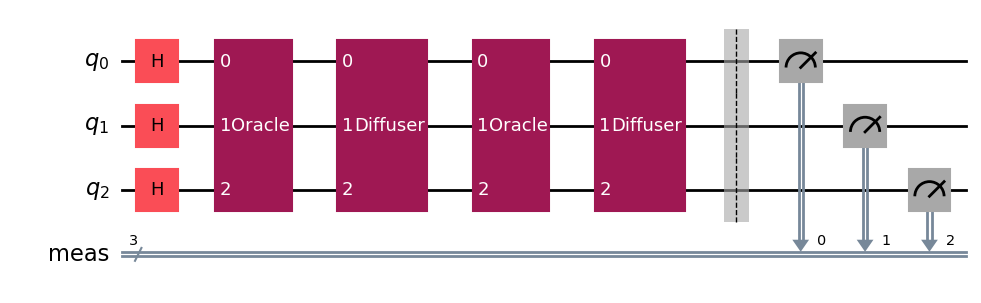

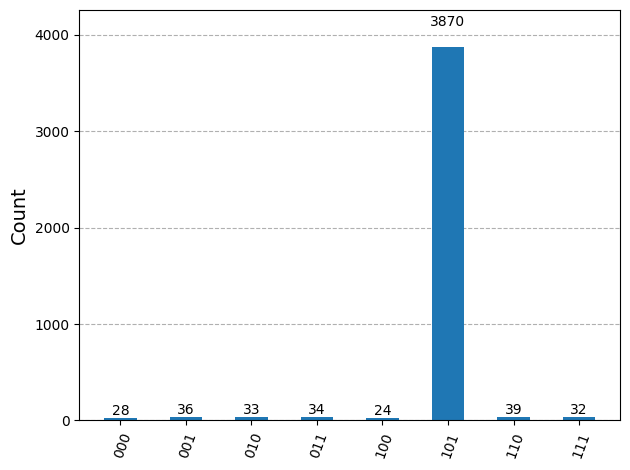

In [10]:
# Parameters
N_QUBITS = 3
TARGET = '101'

# Build circuit
grover_circuit = grover_search(N_QUBITS, TARGET)
grover_circuit.measure_all()
grover_circuit.draw('mpl')

# Run using StatevectorSampler
sampler = StatevectorSampler()
result = sampler.run([grover_circuit], shots=4096).result()
counts = result[0].data.meas.get_counts() # 'meas' stands for 'measurements'

print(f"Target state: |{TARGET}⟩")
print(f"Measured counts: {counts}")

# Show most likely outcome
most_likely = max(counts, key=counts.get)
is_correct_message = f'correct' if most_likely == TARGET else 'wrong'
print(f"Most frequent outcome: |{most_likely}⟩ ({is_correct_message})")

# Plot histogram
_ = plot_histogram(counts) # assigning this to '_' for not representing image again because we are in jupyter